# Demo v6 shape-prior LBS from chunk tracking

This notebook is wired to the current single-camera Demo v6 outputs. It:

1. inspects `outputs/shape_prior_case/shape_prior_frame0`,
2. loads chunk tracking `object_points` from `outputs/online_data/chunks`,
3. uses those object points as LBS controls for the shape-prior mesh,
   `surface_points`, and `interior_points`,
4. writes the derived diagnostic and preview under
   `demo_v6/others/obj_shape_asap_outputs/`.

It does not overwrite `outputs/data/final_data.pkl`.


In [1]:
from pathlib import Path
import sys

import numpy as np

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "demo_v6").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "demo_v6").is_dir():
    raise FileNotFoundError("could not locate repository root containing demo_v6")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from demo_v6.others.lbs_shape_prior_from_chunks import (
    build_lbs_diagnostic,
    build_report as build_lbs_report,
    open_lbs_animation,
    write_lbs_preview,
    write_lbs_diagnostic,
    write_report as write_lbs_report,
)
from demo_v6.others.view_shape_prior_outputs import (
    build_report as build_shape_prior_report,
    load_inspection,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# ===== Demo v6 outputs config =====
OUTPUTS_ROOT = REPO_ROOT / "outputs"
CASE_NAME = "shape_prior_frame0"
CONTROL_K = 8
FRAME_STRIDE = 1

SHAPE_PRIOR_CASE_DIR = OUTPUTS_ROOT / "shape_prior_case" / CASE_NAME
SHAPE_PRIOR_FINAL_DATA = SHAPE_PRIOR_CASE_DIR / "final_data.pkl"
SHAPE_PRIOR_MESH = SHAPE_PRIOR_CASE_DIR / "shape" / "matching" / "final_mesh.glb"
PUBLISHED_FINAL_DATA = OUTPUTS_ROOT / "data" / "final_data.pkl"
CHUNKS_DIR = OUTPUTS_ROOT / "online_data" / "chunks"

ARTIFACT_DIR = REPO_ROOT / "demo_v6" / "others" / "obj_shape_asap_outputs"
LBS_OUTPUT_PATH = ARTIFACT_DIR / "shape_prior_lbs_from_chunks.pkl"
LBS_REPORT_PATH = ARTIFACT_DIR / "shape_prior_lbs_from_chunks.md"
LBS_VIDEO_PATH = ARTIFACT_DIR / "shape_prior_lbs_preview.mp4"
LBS_CONTACT_SHEET_PATH = ARTIFACT_DIR / "shape_prior_lbs_preview_sheet.png"
SHAPE_PRIOR_REPORT_PATH = ARTIFACT_DIR / "shape_prior_outputs_inspection.md"

required_paths = [
    SHAPE_PRIOR_FINAL_DATA,
    SHAPE_PRIOR_MESH,
    PUBLISHED_FINAL_DATA,
    CHUNKS_DIR,
]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("missing Demo v6 output path(s): " + repr(missing))

print("repo root:", REPO_ROOT)
print("shape-prior final_data:", SHAPE_PRIOR_FINAL_DATA)
print("shape-prior mesh:", SHAPE_PRIOR_MESH)
print("published final_data:", PUBLISHED_FINAL_DATA)
print("chunk dir:", CHUNKS_DIR)
print("artifact dir:", ARTIFACT_DIR)
print("LBS diagnostic output:", LBS_OUTPUT_PATH)
print("LBS preview video:", LBS_VIDEO_PATH)

repo root: /home/xinjie/single_proj_qqtt
shape-prior final_data: /home/xinjie/single_proj_qqtt/outputs/shape_prior_case/shape_prior_frame0/final_data.pkl
shape-prior mesh: /home/xinjie/single_proj_qqtt/outputs/shape_prior_case/shape_prior_frame0/shape/matching/final_mesh.glb
published final_data: /home/xinjie/single_proj_qqtt/outputs/data/final_data.pkl
chunk dir: /home/xinjie/single_proj_qqtt/outputs/online_data/chunks
artifact dir: /home/xinjie/single_proj_qqtt/demo_v6/others/obj_shape_asap_outputs
LBS diagnostic output: /home/xinjie/single_proj_qqtt/demo_v6/others/obj_shape_asap_outputs/shape_prior_lbs_from_chunks.pkl
LBS preview video: /home/xinjie/single_proj_qqtt/demo_v6/others/obj_shape_asap_outputs/shape_prior_lbs_preview.mp4


In [3]:
# Inspect the current outputs/shape_prior warmup product.
inspection = load_inspection(OUTPUTS_ROOT, CASE_NAME)
shape_prior_report = build_shape_prior_report(inspection)
SHAPE_PRIOR_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
SHAPE_PRIOR_REPORT_PATH.write_text(shape_prior_report, encoding="utf-8")
print(shape_prior_report)
print("wrote shape-prior report:", SHAPE_PRIOR_REPORT_PATH)

# Demo v6 Shape Prior Outputs Inspection

## Paths

- case: `/home/xinjie/single_proj_qqtt/outputs/shape_prior_case/shape_prior_frame0`
- warmup final data: `/home/xinjie/single_proj_qqtt/outputs/shape_prior_case/shape_prior_frame0/final_data.pkl`
- published final data: `/home/xinjie/single_proj_qqtt/outputs/data/final_data.pkl`

## Warmup Case

- input source: `fake-live`
- depth backend: `native-realsense`
- depth source internal: `realsense`
- object label: `stuffed animal`
- controller label: `hand`

## Masked PCD Stats

processed object mask:
  count: 19,049
  bbox min: [0.0346, -0.0042, -0.0798]
  bbox max: [0.3921, 0.4501, -0.0003]
  mean: [0.1805, 0.2204, -0.0430]
  std: [0.0878, 0.0860, 0.0188]

processed controller mask:
  count: 4,722
  bbox min: [0.0960, -0.0542, -0.1091]
  bbox max: [0.2001, 0.4941, 0.0010]
  mean: [0.1482, 0.2132, -0.0622]
  std: [0.0221, 0.2311, 0.0257]

object/controller overlap pixels: 1

The full depth-valid frame includes background and unrelated pi

In [4]:
# Build LBS trajectories from chunk tracking object points.
lbs_result = build_lbs_diagnostic(
    outputs_root=OUTPUTS_ROOT,
    case_name=CASE_NAME,
    control_k=CONTROL_K,
    frame_stride=FRAME_STRIDE,
)
write_lbs_diagnostic(lbs_result, LBS_OUTPUT_PATH)
write_lbs_report(lbs_result, LBS_REPORT_PATH)
print(build_lbs_report(lbs_result))
print("wrote LBS diagnostic:", LBS_OUTPUT_PATH)
print("wrote LBS report:", LBS_REPORT_PATH)

# Demo v6 Shape-Prior LBS From Chunks

## Inputs

- outputs root: `/home/xinjie/single_proj_qqtt/outputs`
- case: `/home/xinjie/single_proj_qqtt/outputs/shape_prior_case/shape_prior_frame0`
- shape mesh: `/home/xinjie/single_proj_qqtt/outputs/shape_prior_case/shape_prior_frame0/shape/matching/final_mesh.glb`
- chunk count: 23
- query schema hash: `3bef17666c124174ac56e127b88293cc1305e5e376752c4cb7d7a2cae4ea0182`

## LBS Diagnostic

- frames: 805
- chunk object tracking points: 2,001
- mesh vertices: 4,319
- mesh triangles: 6,614
- surface points: 540
- interior points: 1,124
- control K: 8
- frame stride: 1

## Tracking Quality

- object visibility ratio: 90.26%
- object motion-valid ratio: 84.54%
- chunk track status counts: `{'normal': 1, 'degraded': 22}`

The published chunk object points are used as the LBS controls. The
derived mesh/surface/interior trajectories are diagnostics only and do
not overwrite `outputs/data/final_data.pkl`.

wrote LBS diagnostic: /home/xinjie/single_proj

In [5]:
# Check the arrays that will be used for display.
array_keys = [
    "object_points",
    "mesh_vertex_trajectories",
    "surface_trajectories",
    "interior_trajectories",
    "object_visibilities",
    "object_motions_valid",
]
for key in array_keys:
    value = np.asarray(lbs_result[key])
    finite = (
        np.isfinite(value).all() if np.issubdtype(value.dtype, np.number) else "n/a"
    )
    print(f"{key}: shape={value.shape}, dtype={value.dtype}, finite={finite}")

print("summary:", lbs_result["summary"])
print("first source frames:", lbs_result["source_frame_indices"][:10])
print("last source frames:", lbs_result["source_frame_indices"][-10:])

object_points: shape=(805, 2001, 3), dtype=float32, finite=True
mesh_vertex_trajectories: shape=(805, 4319, 3), dtype=float32, finite=True
surface_trajectories: shape=(805, 540, 3), dtype=float32, finite=True
interior_trajectories: shape=(805, 1124, 3), dtype=float32, finite=True
object_visibilities: shape=(805, 2001), dtype=bool, finite=n/a
object_motions_valid: shape=(805, 2001), dtype=bool, finite=n/a
summary: {'frame_count': 805, 'object_point_count': 2001, 'mesh_vertex_count': 4319, 'mesh_triangle_count': 6614, 'surface_point_count': 540, 'interior_point_count': 1124, 'control_k': 8, 'frame_stride': 1, 'chunk_count': 23, 'object_visibility_ratio': 0.902554312905659, 'object_motion_valid_ratio': 0.8454480834117103, 'track_status_counts': {'normal': 1, 'degraded': 22}}
first source frames: [0, 539, 546, 551, 557, 564, 569, 575, 582, 587]
last source frames: [5303, 5310, 5315, 5322, 5327, 5334, 5339, 5345, 5352, 5357]


wrote LBS preview: {'video_path': '/home/xinjie/single_proj_qqtt/demo_v6/others/obj_shape_asap_outputs/shape_prior_lbs_preview.mp4', 'contact_sheet_path': '/home/xinjie/single_proj_qqtt/demo_v6/others/obj_shape_asap_outputs/shape_prior_lbs_preview_sheet.png', 'video_frame_count': 90, 'contact_sheet_frame_count': 12, 'width': 960, 'height': 720, 'fps': 5.0}


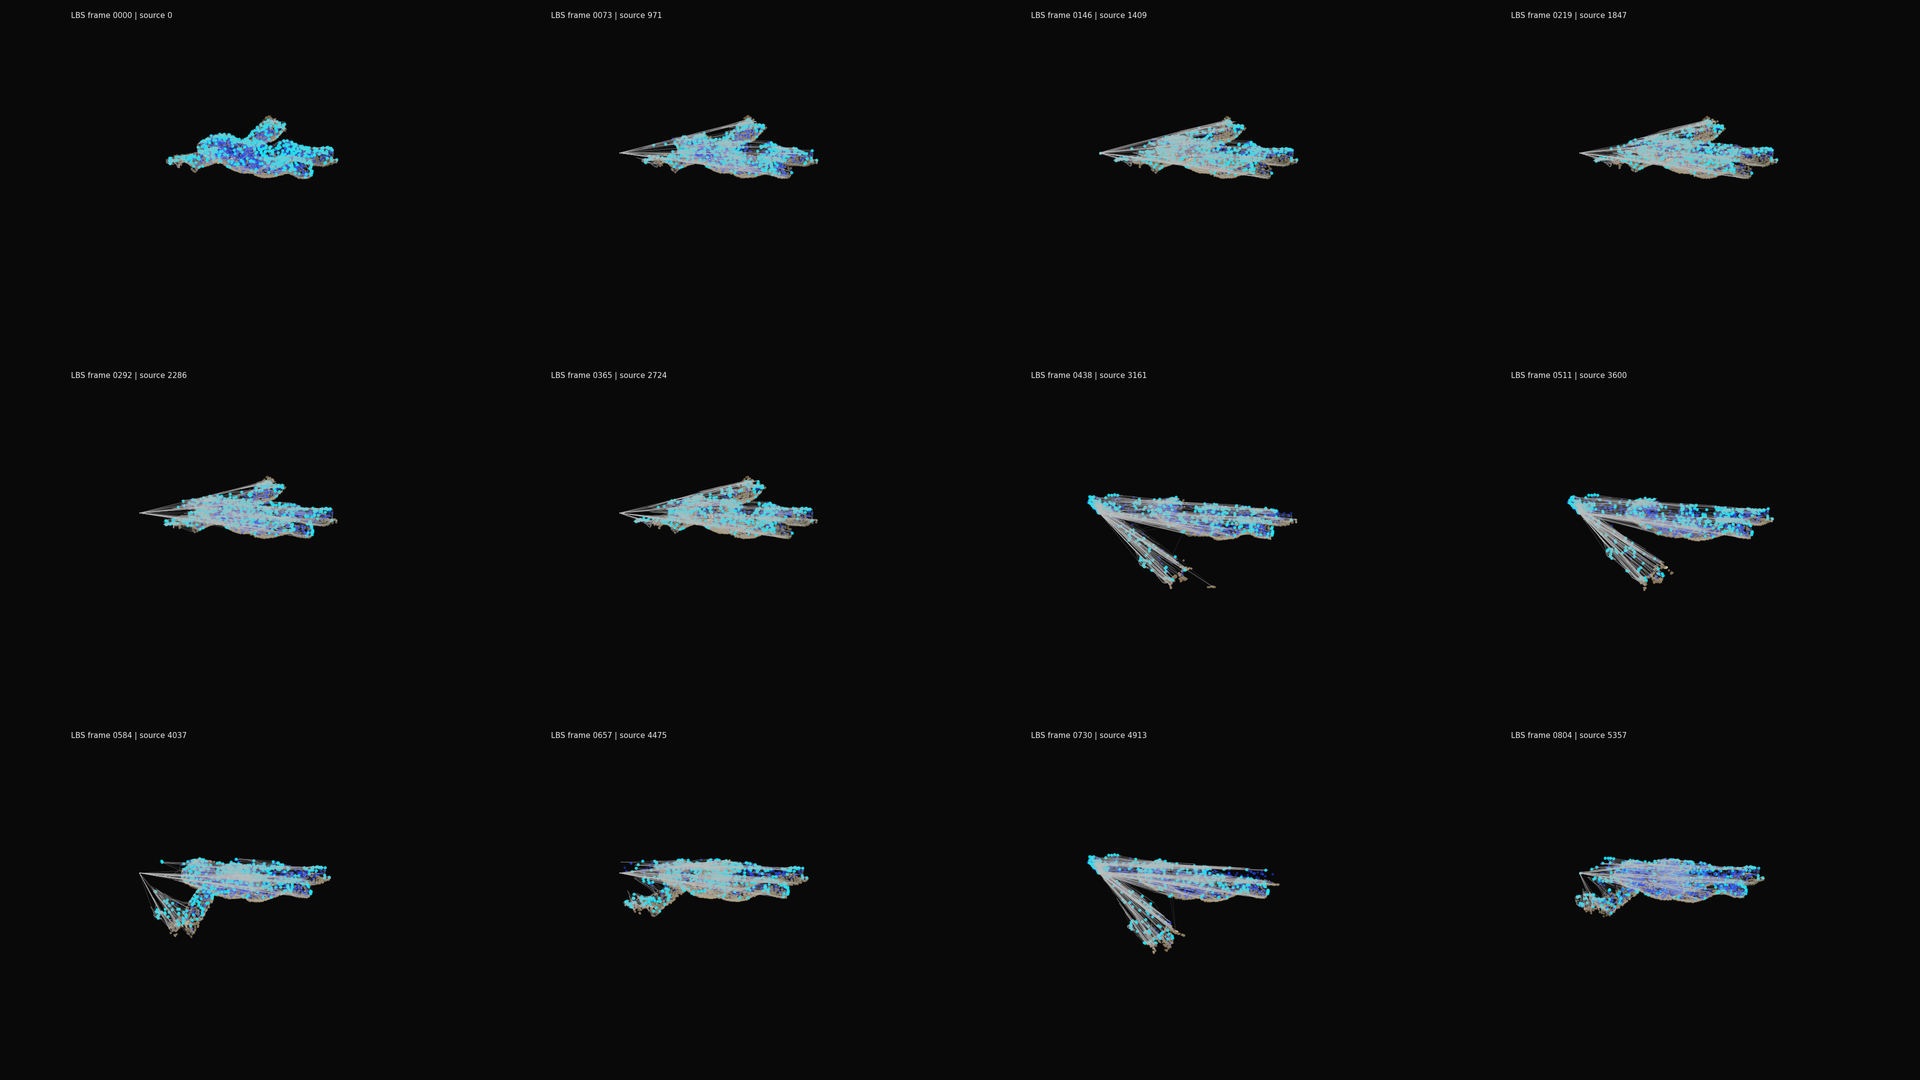

In [6]:
# Render a notebook-visible LBS preview.
from IPython.display import Image, Video, display

preview_info = write_lbs_preview(
    lbs_result,
    video_path=LBS_VIDEO_PATH,
    contact_sheet_path=LBS_CONTACT_SHEET_PATH,
    max_video_frames=90,
    sheet_frames=12,
    fps=5.0,
    width=960,
    height=720,
)
print("wrote LBS preview:", preview_info)
display(Image(filename=str(LBS_CONTACT_SHEET_PATH)))
display(Video(str(LBS_VIDEO_PATH), embed=False, html_attributes="controls loop"))

In [7]:
# Optional Open3D interactive display. Set True when running with a display.
RUN_OPEN3D_VIEWER = False

if RUN_OPEN3D_VIEWER:
    open_lbs_animation(
        lbs_result,
        fps=5.0,
        point_size=4.0,
        pingpong=True,
    )
else:
    print("Open3D viewer skipped. Set RUN_OPEN3D_VIEWER = True to display LBS.")

Open3D viewer skipped. Set RUN_OPEN3D_VIEWER = True to display LBS.
